# 9th attempt – High-Precision Cell Identification

**Goal:** Identify as many alive cells as possible in the **previous** board  
with a **guarantee that every flagged cell is truly alive with ≥ 95% probability**.

## Strategy

1. Train a **multi-output CNN** that emits one sigmoid probability per cell (100 outputs for a 10×10 board).  
2. On the **validation set**, sweep thresholds and pick the lowest one where precision ≥ 0.95.  
3. Apply that threshold at test time → every cell we flag is correct ≥ 95% of the time.

| | Earlier notebooks | This notebook |
|---|---|---|
| Output | Single cell (0/1) | All 100 cells (probabilities) |
| Threshold | 0.5 (default) | Tuned to guarantee ≥ 95% precision |
| Optimises | Accuracy | Precision-constrained recall |
| Metric | F1 / accuracy | Alive cells correctly identified |

In [22]:
import functions
from functions import *
import importlib
importlib.reload(functions)
from functions import *

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from functions import (
    load_reverse_df,
    prepare_full_board_dataset,
    to_numpy_full_board,
    build_and_train_high_precision_cnn,
    find_high_precision_threshold,
    evaluate_high_precision,
)

In [24]:
SIZE           = 10
AMOUNT_BOARDS  = 1000
gen            = 2      # 1 current board (features) + 1 previous board (targets)
TARGET_PRECISION = 0.7

## 1. Load data

In [25]:
reverse_df = load_reverse_df(SIZE, AMOUNT_BOARDS, gen)
print("DataFrame shape:", reverse_df.shape)
print("Columns:", reverse_df.shape[1], "  (first 100 = current board, last 100 = previous board)")

DataFrame shape: (41366, 200)
Columns: 200   (first 100 = current board, last 100 = previous board)


## 2. Prepare dataset

- **X** = columns 0-99   → the *current* board (one step later)  
- **y** = columns 100-199 → ALL cells of the *previous* board (what we want to recover)

In [26]:
X_train, X_val, X_test, y_train, y_val, y_test = prepare_full_board_dataset(
    reverse_df, SIZE, gen, test_size=0.1, val_size=0.1, random_state=365
)

print(f"Train : {len(X_train):>7,}")
print(f"Val   : {len(X_val):>7,}")
print(f"Test  : {len(X_test):>7,}")

# Average alive-cell fraction in the previous board
alive_frac = y_train.to_numpy().mean()
print(f"\nAverage alive-cell fraction in previous board: {alive_frac:.3f}  ({alive_frac*100:.1f}%)")

Train :  33,506
Val   :   3,723
Test  :   4,137

Average alive-cell fraction in previous board: 0.203  (20.3%)


## 3. Convert to numpy

In [27]:
X_tr, X_v, X_te, y_tr, y_v, y_te = to_numpy_full_board(
    X_train, X_val, X_test, y_train, y_val, y_test, SIZE
)

print("X_train shape:", X_tr.shape)   # (N, 10, 10, 1)
print("y_train shape:", y_tr.shape)   # (N, 100)

X_train shape: (33506, 10, 10, 1)
y_train shape: (33506, 100)


## 4. Build and train the multi-output CNN

The model outputs **100 independent sigmoid probabilities** — one per cell of the previous board.

```
Input (10,10,1)
  Conv2D(64,  3×3, same) + BN
  Conv2D(128, 3×3, same) + BN
  Conv2D(128, 3×3, same) + BN
  Flatten
  Dense(512) + Dropout(0.3)
  Dense(256) + Dropout(0.2)
  Dense(100, sigmoid)          ← probability for each previous-board cell
```

In [28]:
model, history = build_and_train_high_precision_cnn(
    X_tr, y_tr,
    size=SIZE,
    epochs=40,
    batch_size=256,
    validation_split=0.2,
)
model.summary()

Epoch 1/40
105/105 ━━━━━━━━━━━━━━━━━━━━ 53s 481ms/step - accuracy: 0.0216 - loss: 0.5006 - val_accuracy: 0.0036 - val_loss: 0.6171 - learning_rate: 0.0010
Epoch 2/40
105/105 ━━━━━━━━━━━━━━━━━━━━ 75s 414ms/step - accuracy: 0.0248 - loss: 0.4076 - val_accuracy: 0.0100 - val_loss: 0.6122 - learning_rate: 0.0010
Epoch 3/40
105/105 ━━━━━━━━━━━━━━━━━━━━ 45s 428ms/step - accuracy: 0.0263 - loss: 0.3873 - val_accuracy: 0.1013 - val_loss: 0.5754 - learning_rate: 0.0010
Epoch 4/40
105/105 ━━━━━━━━━━━━━━━━━━━━ 76s 372ms/step - accuracy: 0.0306 - loss: 0.3699 - val_accuracy: 0.0282 - val_loss: 0.5823 - learning_rate: 0.0010
Epoch 5/40
105/105 ━━━━━━━━━━━━━━━━━━━━ 46s 437ms/step - accuracy: 0.0311 - loss: 0.3567 - val_accuracy: 0.0339 - val_loss: 0.4388 - learning_rate: 0.0010
Epoch 6/40
105/105 ━━━━━━━━━━━━━━━━━━━━ 63s 606ms/step - accuracy: 0.0351 - loss: 0.3459 - val_accuracy: 0.0403 - val_loss: 0.3684 - learning_rate: 0.0010
Epoch 7/40
105/105 ━━━━━━━━━━━━━━━━━━━━ 46s 438ms/step - accuracy: 0.0

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 10, 10, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 10, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 10, 10, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 10, 10, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 10, 10, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     6,554,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,802,222 (79.35 MB)

 Trainable params: 6,933,860 (26.45 MB)

 Non-trainable params: 640 (2.50 KB)

 Optimizer params: 13,867,722 (52.90 MB)

## 5. Training curves

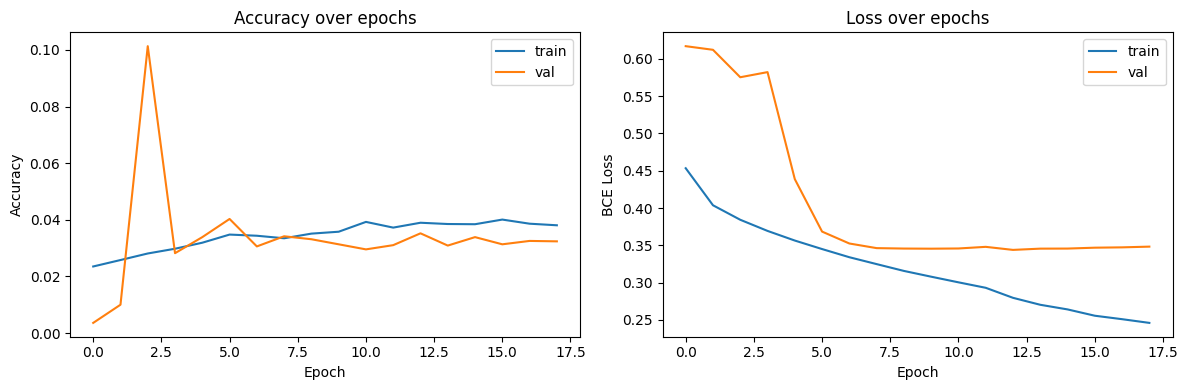

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy over epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()

axes[1].plot(history.history['loss'],     label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss over epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('BCE Loss'); axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Find the high-precision threshold

We search the **validation set** for the lowest threshold where precision ≥ 95%.  
This ensures that every cell we flag as *alive* is correct at least 95% of the time.

In [30]:
threshold, val_precision, val_recall, precisions, recalls, thresholds = \
    find_high_precision_threshold(model, X_v, y_v, target_precision=TARGET_PRECISION)


===== Threshold search  (target precision ≥ 70%) =====
Optimal threshold             : 0.6020
Precision at threshold        : 0.700  (70.0%)
Recall at threshold           : 0.373  (37.3%)
Alive cells identified        : 40,127 / 75,213


### Precision-Recall curve

C:\Users\דרור\AppData\Local\Temp\ipykernel_13488\667568766.py:27: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


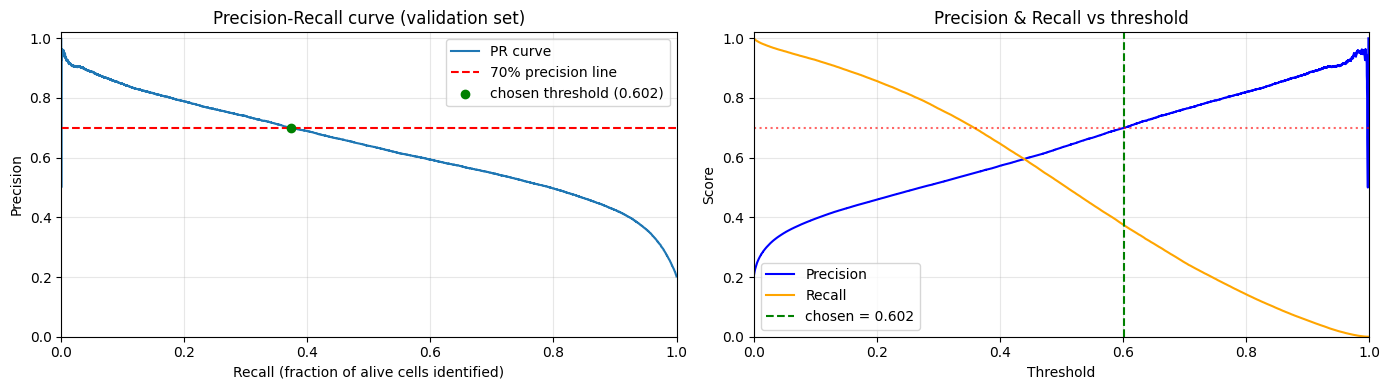

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Left: PR curve ---
axes[0].plot(recalls, precisions, lw=1.5, label='PR curve')
axes[0].axhline(TARGET_PRECISION, color='red', linestyle='--', label=f'{TARGET_PRECISION:.0%} precision line')
axes[0].scatter([val_recall], [val_precision], color='green', zorder=5,
                label=f'chosen threshold ({threshold:.3f})')
axes[0].set_xlabel('Recall (fraction of alive cells identified)')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall curve (validation set)')
axes[0].legend()
axes[0].set_xlim([0, 1]); axes[0].set_ylim([0, 1.02])
axes[0].grid(True, alpha=0.3)

# --- Right: Precision / Recall vs threshold ---
axes[1].plot(thresholds, precisions[:-1], label='Precision', color='blue')
axes[1].plot(thresholds, recalls[:-1],    label='Recall',    color='orange')
axes[1].axvline(threshold, color='green', linestyle='--', label=f'chosen = {threshold:.3f}')
axes[1].axhline(TARGET_PRECISION, color='red', linestyle=':', alpha=0.6)
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision & Recall vs threshold')
axes[1].legend()
axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.02])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Evaluate on test set

In [32]:
y_proba, y_pred, y_true = evaluate_high_precision(model, X_te, y_te, threshold)


===== High-Precision Evaluation  (threshold = 0.6020) =====
Cells flagged as alive          :   44,699
  ↳ truly alive  (TP)           :   31,334   precision = 70.1%
  ↳ false alarms (FP)           :   13,365
Total truly alive cells         :   84,354
Recall  (alive cells caught)    :    37.1%
F1-score                        :    0.486


## 8. Probability distribution of predictions

Shows how the model separates truly-alive cells from dead ones.

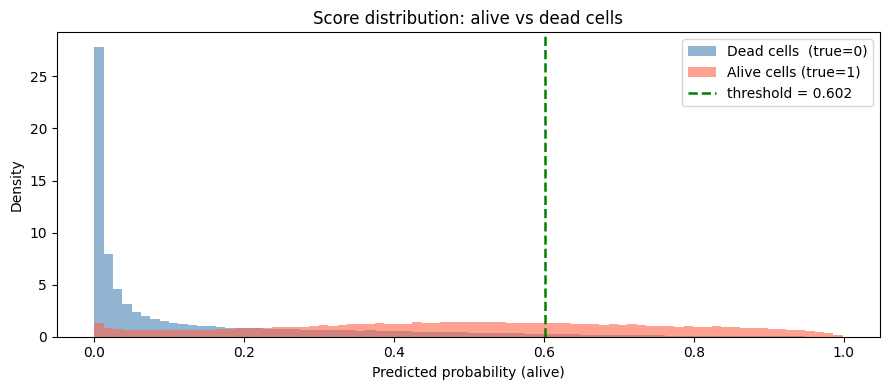

In [33]:
proba_flat = y_proba.flatten()
true_flat  = y_true.flatten()

plt.figure(figsize=(9, 4))
plt.hist(proba_flat[true_flat == 0], bins=80, alpha=0.6, color='steelblue',
         label='Dead cells  (true=0)', density=True)
plt.hist(proba_flat[true_flat == 1], bins=80, alpha=0.6, color='tomato',
         label='Alive cells (true=1)', density=True)
plt.axvline(threshold, color='green', linestyle='--', linewidth=1.8,
            label=f'threshold = {threshold:.3f}')
plt.xlabel('Predicted probability (alive)')
plt.ylabel('Density')
plt.title('Score distribution: alive vs dead cells')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Per-cell precision across the board

Heat-map of how reliable the model is **at each board position**.

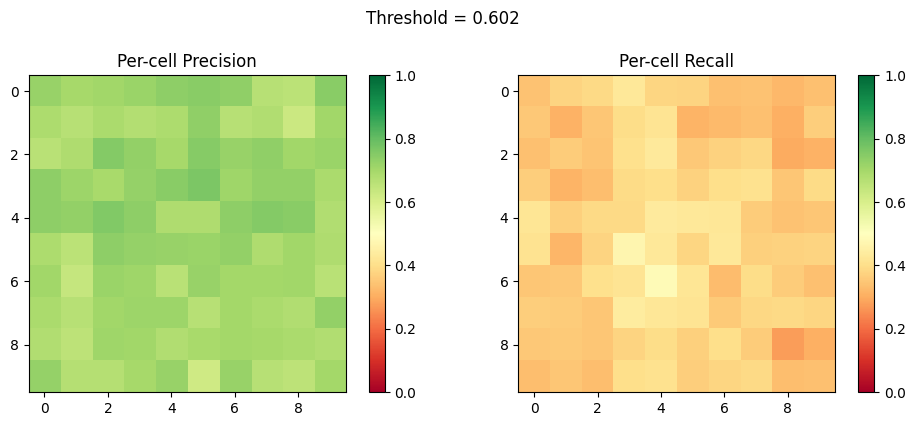

In [34]:
per_cell_precision = np.full(SIZE * SIZE, np.nan)
per_cell_recall    = np.full(SIZE * SIZE, np.nan)

for c in range(SIZE * SIZE):
    pred_c = y_pred[:, c]
    true_c = y_true[:, c]
    tp_c = np.sum((pred_c == 1) & (true_c == 1))
    fp_c = np.sum((pred_c == 1) & (true_c == 0))
    fn_c = np.sum((pred_c == 0) & (true_c == 1))
    if tp_c + fp_c > 0:
        per_cell_precision[c] = tp_c / (tp_c + fp_c)
    if tp_c + fn_c > 0:
        per_cell_recall[c] = tp_c / (tp_c + fn_c)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(per_cell_precision.reshape(SIZE, SIZE),
                     vmin=0, vmax=1, cmap='RdYlGn')
axes[0].set_title('Per-cell Precision')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(per_cell_recall.reshape(SIZE, SIZE),
                     vmin=0, vmax=1, cmap='RdYlGn')
axes[1].set_title('Per-cell Recall')
plt.colorbar(im1, ax=axes[1])

plt.suptitle(f'Threshold = {threshold:.3f}', y=1.02)
plt.tight_layout()
plt.show()

## 10. Example boards: what the model identifies

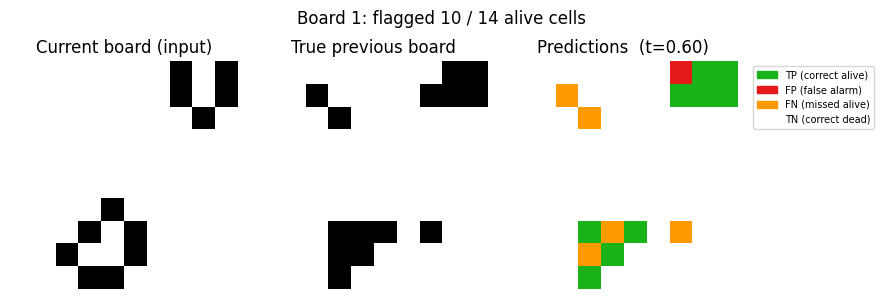

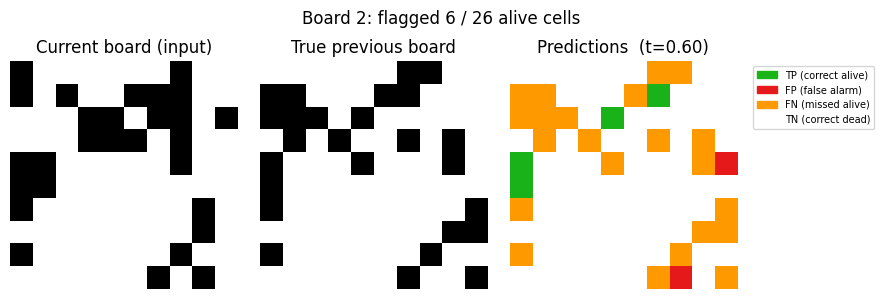

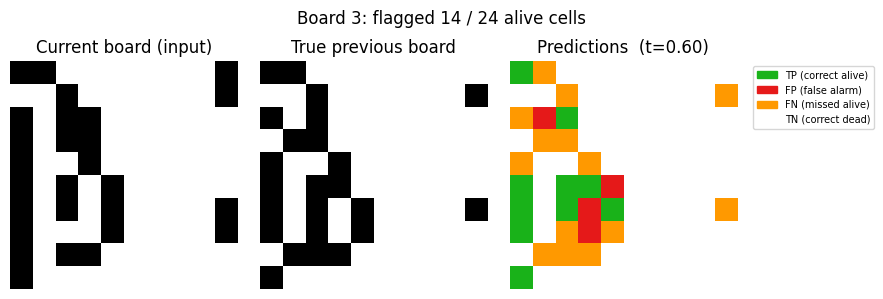

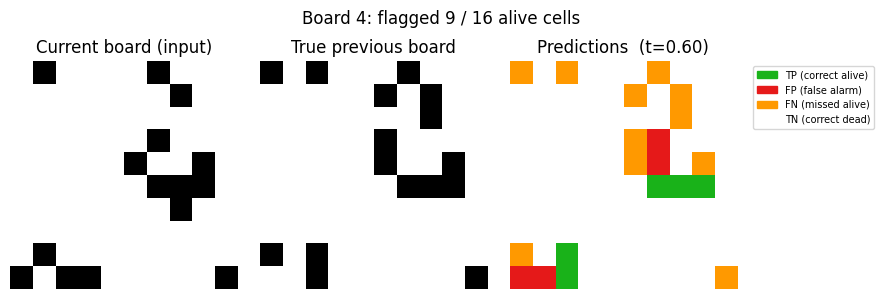

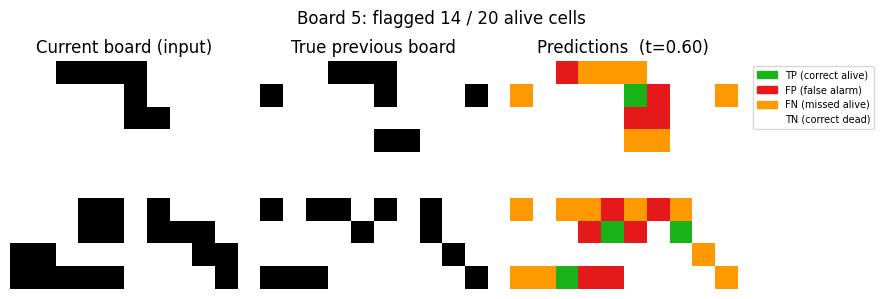

In [35]:
def plot_board_trio(current, true_prev, pred_prev, title='', threshold=0.5):
    """Show current board, true previous board, and model's high-precision predictions."""
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    size = int(np.sqrt(len(true_prev)))

    pred_board = (pred_prev.reshape(size, size) >= threshold).astype(int)
    true_board = true_prev.reshape(size, size)

    # Colour map: 0=white, 1=black
    kw = dict(cmap='Greys', vmin=0, vmax=1, interpolation='nearest')
    axes[0].imshow(current.reshape(size, size), **kw)
    axes[0].set_title('Current board (input)')

    axes[1].imshow(true_board, **kw)
    axes[1].set_title('True previous board')

    # Colour-code predictions:
    #   TP = green, FP = red, FN = orange (missed alive), TN = white
    rgb = np.ones((size, size, 3))
    tp_mask = (pred_board == 1) & (true_board == 1)
    fp_mask = (pred_board == 1) & (true_board == 0)
    fn_mask = (pred_board == 0) & (true_board == 1)
    rgb[tp_mask] = [0.1, 0.7, 0.1]   # green
    rgb[fp_mask] = [0.9, 0.1, 0.1]   # red
    rgb[fn_mask] = [1.0, 0.6, 0.0]   # orange

    axes[2].imshow(rgb, interpolation='nearest')
    axes[2].set_title(f'Predictions  (t={threshold:.2f})')

    patches = [
        mpatches.Patch(color=[0.1,0.7,0.1], label='TP (correct alive)'),
        mpatches.Patch(color=[0.9,0.1,0.1], label='FP (false alarm)'),
        mpatches.Patch(color=[1.0,0.6,0.0], label='FN (missed alive)'),
        mpatches.Patch(color=[1.0,1.0,1.0], label='TN (correct dead)'),
    ]
    axes[2].legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)

    for ax in axes:
        ax.axis('off')
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


# Show 5 random test boards
rng = np.random.default_rng(42)
sample_idx = rng.integers(0, len(X_te), size=5)

for i, idx in enumerate(sample_idx):
    n_flagged = int(y_pred[idx].sum())
    n_alive   = int(y_true[idx].sum())
    plot_board_trio(
        current=X_te[idx],
        true_prev=y_true[idx],
        pred_prev=y_proba[idx],
        title=f'Board {i+1}: flagged {n_flagged} / {n_alive} alive cells',
        threshold=threshold,
    )